# Build a model

Are the signals from `pbs-1`, `pbs-2`, and `pbs-3` sufficiently discrimatory of human breast cancer?


```
variation.update({
    'q_high': 0.95
})
```

## 0. Initializations

In [1]:
## 0. Initializations
# -- imports --
import anndata as ad
import gseapy as gp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns

import random

from collections import defaultdict

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from statistics import median

from signals_in_the_noise.analysis.noise_phenotypes import classify_noise_subtypes
from signals_in_the_noise.preprocessing.gse161529 import GSE161529

In [2]:
# -- datasets --
gse = GSE161529()

## 1. Preprocessing Data

1. Subset data to samples that have a potential biological signal.
2. Determine the distribution of number of samples per subject - use to downsample for parity.
3. Determine the distribution of number of cells per subject - use to downsample for parity

In [3]:
from signals_in_the_noise.analysis.noise_phenotypes import PbsThresholds, Thresholds

pbs_1_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=0.85, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
)
pbs_2_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=0.25, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_total_counts=Thresholds(q_low=0.3, q_high=None, q_mod_low=None, q_mod_high=None),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.45, q_mod_high=0.85),
)
pbs_3_thresholds = PbsThresholds(
    pct_counts_mt=Thresholds(q_low=None, q_high=None, q_mod_low=0.3, q_mod_high=0.65),
    log1p_total_counts=Thresholds(q_low=None, q_high=None, q_mod_low=0.5, q_mod_high=0.85),
    log1p_n_genes_by_counts=Thresholds(q_low=None, q_high=0.95, q_mod_low=None, q_mod_high=None),
)

In [4]:
# -- subset data --
subtype_to_adata = defaultdict(dict)
choices = ["pbs-1", "pbs-2", "pbs-3"]
for adata in gse.objects.values():
    if adata.uns['cell_population'] != 'Total':
        continue
    adata_noise = adata[adata.obs["is_noise"] == 1].copy()
    classify_noise_subtypes(adata_noise, pbs_thresholds={
        "pbs-1": pbs_1_thresholds,
        "pbs-2": pbs_2_thresholds,
        "pbs-3": pbs_3_thresholds,
})
    conditions = [
        adata_noise.obs["pbs-1"] == 1,
        adata_noise.obs["pbs-2"] == 1,
        adata_noise.obs["pbs-3"] == 1,
    ]
    adata_noise.obs["pbs"] = np.select(conditions, choices, default="none")
    adata_pbs_only = adata_noise[adata_noise.obs["pbs"] != "none"]
    subtype_to_adata[adata_pbs_only.uns['cancer_type']].update({
        adata_pbs_only.uns['title'] : adata_pbs_only
    })

In [5]:
subtype_to_adata.keys()

dict_keys(['Normal', 'BRCA1 pre-neoplastic', 'Triple negative tumour', 'Triple negative BRCA1 tumour', 'HER2+ tumour', 'PR+ tumour', 'ER+ tumour'])

In [6]:
def print_data_stats(adata_collection):
    results = []
    for subtype, adatas in adata_collection.items():
        num_subjects = len(adatas)
        num_samples = [adata.n_obs for adata in adatas.values()]
        print(f"{subtype} - {num_samples}")
        results.append((subtype, num_subjects, min(num_samples), median(num_samples)))
    
    return pd.DataFrame(results, columns=['Cancer sub-type', '# Subjects', 'Min # Samples', 'Median # Samples'])

print_data_stats(subtype_to_adata)

Normal - [33, 94, 460, 12, 22, 37, 6, 39, 47, 37, 34, 51, 147]
BRCA1 pre-neoplastic - [46, 47, 68, 67]
Triple negative tumour - [31, 52, 20, 61]
Triple negative BRCA1 tumour - [32, 54, 40, 132]
HER2+ tumour - [35, 139, 28, 4, 25, 505]
PR+ tumour - [15]
ER+ tumour - [125, 122, 113, 68, 14, 43, 118, 35, 22, 51, 53, 66, 81, 6, 202, 28, 358, 13]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,13,6,37.0
1,BRCA1 pre-neoplastic,4,46,57.0
2,Triple negative tumour,4,20,41.5
3,Triple negative BRCA1 tumour,4,32,47.0
4,HER2+ tumour,6,4,31.5
5,PR+ tumour,1,15,15.0
6,ER+ tumour,18,6,59.5


### 1.a. Decisions

1. Exclude cancer sub-type `PR+ tumour` because there is only a single subject in the dataset.
2. Downsample subjects to `3` with a minimum of `50` samples.

### 1.b. Further subset data

Produces a dataset with the decisions.

In [7]:
def subset_data_for_modeling(require_min_subject=True, require_min_samples=True):
    results = {}
    for subtype, adatas in subtype_to_adata.items():
        if require_min_subject and subtype == 'PR+ tumour':
            # only has one subject, exclude
            continue
        valid_subjects_to_adata = defaultdict(dict)
        for adata in adatas.values():
            if require_min_samples and adata.n_obs < 50:
                # exclude subjects with fewer than 50 samples
                continue
            valid_subjects_to_adata.update({
                adata.uns['title']: adata,
            })
        results[subtype] = valid_subjects_to_adata
    return results
valid_adatas = subset_data_for_modeling()

In [8]:
print_data_stats(valid_adatas)

Normal - [94, 460, 51, 147]
BRCA1 pre-neoplastic - [68, 67]
Triple negative tumour - [52, 61]
Triple negative BRCA1 tumour - [54, 132]
HER2+ tumour - [139, 505]
ER+ tumour - [125, 122, 113, 68, 118, 51, 53, 66, 81, 202, 358]


,Cancer sub-type,# Subjects,Min # Samples,Median # Samples
0,Normal,4,51,120.5
1,BRCA1 pre-neoplastic,2,67,67.5
2,Triple negative tumour,2,52,56.5
3,Triple negative BRCA1 tumour,2,54,93.0
4,HER2+ tumour,2,139,322.0
5,ER+ tumour,11,51,113.0


### 1.3. Utility to Generate Dataset for Modeling

Creates a list of dataframe from the AnnDatas that represents all cancer sub-types (except for `PR+ tumour`), with the following characteristics:

1. `3` subjects per sub-type, `6` sub-types = `18` total subjects
2. `1` dataframe per subject
3. Columns
   1. `has_cancer`
   2. `cancer_type`
   3. `cell_population`
   4. `menopause_status`
   5. `pbs-1`
   6. `pbs-2`
   7. `pbs-3`

Separating the subjects to a row will simplify using the leave-one-out strategy.

In [9]:
def generate_dataframe_for_modeling(adata, *, downsample=True):
    results = []
    for adatas in adata.values():
        if downsample:
            subjects = np.random.choice(list(adatas.keys()), 3)
        else:
            subjects = adatas.keys()

        for subject in subjects:
            adata = adatas[subject]
            df = pd.DataFrame({
                'pbs-1': adata.obs['pbs-1'].astype(int),
                'pbs-2': adata.obs['pbs-2'].astype(int),
                'pbs-3': adata.obs['pbs-3'].astype(int),
            })
            df['has_cancer'] = (adata.uns['cancer_type'] != 'Normal')
            df['cancer_type'] = str(adata.uns['cancer_type'])
            df['cell_population'] = str(adata.uns['cell_population'])
            df['menopause_status'] = str(adata.uns['menopause_status'])
            
            results.append(df)
    return results

In [10]:
generate_dataframe_for_modeling(adata=valid_adatas)[0]

,pbs-1,pbs-2,pbs-3,has_cancer,cancer_type,cell_population,menopause_status
AAATGGACAATCCTTT-1,0,1,0,False,Normal,Total,Pre
AACAAAGGTTGTCCCT-1,0,1,0,False,Normal,Total,Pre
AACAAGAGTAACATGA-1,0,1,0,False,Normal,Total,Pre
AACACACGTCGGCCTA-1,0,1,0,False,Normal,Total,Pre
AACCACACATCGTGGC-1,0,1,0,False,Normal,Total,Pre
...,...,...,...,...,...,...,...
TTTACTGCAGTATTCG-1,0,1,0,False,Normal,Total,Pre
TTTAGTCCAACATCGT-1,1,0,0,False,Normal,Total,Pre
TTTAGTCGTTAGGCCC-1,0,1,0,False,Normal,Total,Pre
TTTGTTGCAAGCACCC-1,0,1,0,False,Normal,Total,Pre


## 2. Build the classifier

In [11]:
def logistic_regression_loo_classifier(dfs, *, by_subjects=True, as_dict=False, model=None, target='cancer_type'):
    loo = LeaveOneOut()
    y_true, y_pred = [], []
    
    for train_idx, test_idx in loo.split(dfs):
        train_df = pd.concat([dfs[i] for i in train_idx])
        # there will only ever be one in the test
        test_df = dfs[test_idx[0]]
    
        X_train = train_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_train = train_df[target].values
    
        X_test = test_df[['pbs-1', 'pbs-2', 'pbs-3']].values
        y_test = test_df[target].values

        if not model:
            model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
    
        if by_subjects:
            counts = np.unique(model.predict(X_test), return_counts=True)
            # return the majority vote for the subject
            y_pred.append(counts[0][np.argmax(counts[1])])
            y_true.append(test_df[target].iloc[0])
        else:
            y_pred.extend(model.predict(X_test))
            y_true.extend(y_test)
    
    return classification_report(y_true, y_pred, output_dict=as_dict)

### 2.1. Explore other models

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import warnings
from sklearn.exceptions import UndefinedMetricWarning

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'KNN': KNeighborsClassifier(n_neighbors=3, weights='distance'),
    'Naive Bayes': GaussianNB()
}

### 2.2. Model ANY cancer

#### 2.3.1 Need to downsample to proceed

The data is not balanced in several ways:
- Subjects skew to having cancer
- Sample count per subject varies

To address this, build several models for different views that are more balanced:
- Normal vs Abnormal
  - Abnormal can be any combination of cancer subjects. For example, group cancer by comparable subject count.
- Subset subjects to get a balanced 

In [13]:
dfs = generate_dataframe_for_modeling(adata=valid_adatas, downsample=False)

In [14]:
dfs_cancer = []
dfs_normal = []

for df in dfs:
    if df['cancer_type'].unique()[0] == 'Normal':
        dfs_normal.append(df)
    else:
        dfs_cancer.append(df)

In [15]:
def get_balanced_dataset(minority_dfs, majority_dfs, num_minority_subjects=6):
    # select the normal subjects first, its the smaller number of total subjects
    some_minority = random.sample(minority_dfs, k=min(num_minority_subjects, len(minority_dfs)))
    # total number of cells (samples) to use for downsampling the abnormal (cancer) subjects
    num_minority_cells = sum([df.count().unique()[0] for df in some_minority])

    majority_pool = majority_dfs.copy()
    some_majority = []
    num_majority_cells = 0
    # iterate over cancer subjects
    for _ in majority_dfs:
        major = majority_pool.pop(random.randrange(len(majority_pool)))
        major_count = major.count().unique()[0]
        if major_count > num_minority_cells:
            continue
        some_majority.append(major)
        num_majority_cells += major_count
        if num_majority_cells >= num_minority_cells:
            break

    # print(num_majority_cells, num_minority_cells)
    return some_minority, some_majority
    
balanced_dfs_normal, balanced_dfs_cancer = get_balanced_dataset(dfs_normal, dfs_cancer)   

In [16]:
def report_has_cancer(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                balanced_dfs_normal, dfs = get_balanced_dataset(minority, majority)
                dfs.extend(balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model, target="has_cancer")
                reports.append(pd.DataFrame(report).T)
        
            avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {avg_report}")
            print()
            model_avg_report[model_name] = avg_report
        return model_avg_report

report_has_cancer(dfs_normal, dfs_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
False          0.708079  0.812500  0.755422   752.000000
True           0.813506  0.709685  0.756748   887.700000
accuracy       0.757097  0.757097  0.757097     0.757097
macro avg      0.760792  0.761092  0.756085  1639.700000
weighted avg   0.766608  0.757097  0.757033  1639.700000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
False          0.707761  0.812500  0.755255   752.000000
True           0.806176  0.699004  0.747181   860.330000
accuracy       0.752415  0.752415  0.752415     0.752415
macro avg      0.756969  0.755752  0.751218  1612.330000
weighted avg   0.761379  0.752415  0.751774  1612.330000

Model: KNN
-------------------------
Mean:               precision    recall  f1-score     support
False          0.000000  0.000000  0.000000   752.00000
True           0.537576  0.995267  0.697409   8

{'Logistic Regression':               precision    recall  f1-score      support
 False          0.708079  0.812500  0.755422   752.000000
 True           0.813506  0.709685  0.756748   887.700000
 accuracy       0.757097  0.757097  0.757097     0.757097
 macro avg      0.760792  0.761092  0.756085  1639.700000
 weighted avg   0.766608  0.757097  0.757033  1639.700000,
 'Decision Tree':               precision    recall  f1-score      support
 False          0.707761  0.812500  0.755255   752.000000
 True           0.806176  0.699004  0.747181   860.330000
 accuracy       0.752415  0.752415  0.752415     0.752415
 macro avg      0.756969  0.755752  0.751218  1612.330000
 weighted avg   0.761379  0.752415  0.751774  1612.330000,
 'KNN':               precision    recall  f1-score     support
 False          0.000000  0.000000  0.000000   752.00000
 True           0.537576  0.995267  0.697409   889.38000
 accuracy       0.536340  0.536340  0.536340     0.53634
 macro avg      0.268788  0

In [17]:
def report_cancer_sub_types(minority, majority):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
        n_runs = 100
        model_avg_report = {}
        for model_name, model in models.items():
            reports = []
            for run in range(n_runs):
                balanced_dfs_normal, dfs = get_balanced_dataset(minority, majority)
                dfs.extend(balanced_dfs_normal)
                
                report = logistic_regression_loo_classifier(dfs, by_subjects=False, as_dict=True, model=model)
                reports.append(pd.DataFrame(report).T)
        
            avg_report = pd.concat(reports).groupby(level=0).mean()
        
            print(f"{'='*25}")
            print(f"Model: {model_name}")
            print(f"{'-'*25}")
            print(f"Mean: {avg_report}")
            print()
            model_avg_report[model_name] = avg_report
        return model_avg_report

# report_cancer_sub_types(dfs_normal, dfs_cancer)

In [18]:
targets = ['ER+ tumour',]
dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
avg_reports = report_cancer_sub_types(dfs_normal, dfs_target_cancer)

Model: Logistic Regression
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.829400  0.801288  0.814798   865.670000
Normal         0.782314  0.812500  0.796756   752.000000
accuracy       0.806688  0.806688  0.806688     0.806688
macro avg      0.805857  0.806894  0.805777  1617.670000
weighted avg   0.808210  0.806688  0.806858  1617.670000

Model: Decision Tree
-------------------------
Mean:               precision    recall  f1-score      support
ER+ tumour     0.824665  0.801127  0.812463   835.590000
Normal         0.787986  0.812500  0.799761   752.000000
accuracy       0.806717  0.806717  0.806717     0.806717
macro avg      0.806326  0.806814  0.806112  1587.590000
weighted avg   0.807779  0.806717  0.806794  1587.590000

Model: KNN
-------------------------
Mean:               precision   recall  f1-score     support
ER+ tumour     0.531790  1.00000   0.69402   858.59000
Normal         0.000000  0.00000   0.00000   752.

In [19]:
# targets = ['HER2+ tumour', 'Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [20]:
# targets = ['Triple negative tumour', 'Triple negative BRCA1 tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [21]:
# targets = ['Triple negative tumour']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [22]:
# targets = ['BRCA1 pre-neoplastic']
# dfs_target_cancer = [df for df in dfs_cancer if df['cancer_type'].unique()[0] in targets]
# report_has_cancer(dfs_target_cancer, dfs_normal)

In [23]:
def figure_for_poster(avg_report, minority_label="True", majority_label="False", small=False):
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np
    
    # ── DATA from avg_report ─────────────────────────────────────────────────────
    support_false   = avg_report.loc[majority_label,     "support"]
    support_true    = avg_report.loc[minority_label,      "support"]
    recall_false    = avg_report.loc[majority_label,     "recall"]
    recall_true     = avg_report.loc[minority_label,      "recall"]
    precision_false = avg_report.loc[majority_label,     "precision"]
    precision_true  = avg_report.loc[minority_label,      "precision"]
    f1_false        = avg_report.loc[majority_label,     "f1-score"]
    f1_true         = avg_report.loc[minority_label,      "f1-score"]
    accuracy        = avg_report.loc["accuracy",  "f1-score"]
    macro_f1        = avg_report.loc["macro avg", "f1-score"]
    
    tn = round(support_false * recall_false)
    fp = round(support_false * (1 - recall_false))
    fn = round(support_true  * (1 - recall_true))
    tp = round(support_true  * recall_true)
    
    cm      = np.array([[tn, fp], [fn, tp]])
    support = [support_false, support_true]
    blue    = "#0072B2"
    orange  = "#D55E00"
    
    # ── FIGURE ───────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(8, 5))
    
    ax_cm     = fig.add_axes([0.05, 0.10, 0.50, 0.80])

    if small:
        font_sizes = [26, 20, 20]
    else:
        font_sizes = [32, 26, 20]
    
    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────────
    if small:
        classes = [f"{minority_label}", f"{majority_label}"]
    else:
        classes = [f"{minority_label}\n(no cancer)", f"{majority_label}\n(cancer)"]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = val / support[i] if support[i] > 0 else 0
     
            if i == j:
                color = blue
                alpha = 0.15 + pct * 0.75
            else:
                color = orange
                alpha = 0.10 + pct * 0.70

            if small:
                rect = patches.FancyBboxPatch(
                    (j + 0.08, 1 - i + 0.08), 0.84, 0.84,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            else:
                rect = patches.FancyBboxPatch(
                    (j + 0.04, 1 - i + 0.04), 0.92, 0.92,
                    boxstyle="round,pad=0.02",
                    facecolor=color, alpha=max(alpha, 0.08),
                    linewidth=0
                )
            ax_cm.add_patch(rect)
     
            text_color = "#00274C"
            if small:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.35, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
            else:
                ax_cm.text(j + 0.5, 1 - i + 0.60, f"{int(val):,}",
                           ha="center", va="center",
                           fontsize=font_sizes[0], fontweight="500", color=text_color)
                ax_cm.text(j + 0.5, 1 - i + 0.28, f"{pct:.1%}",
                           ha="center", va="center",
                           fontsize=font_sizes[1], color=text_color, alpha=0.85)
     
    ax_cm.set_xticks([0.5, 1.5])
    ax_cm.set_xticklabels(classes, fontsize=font_sizes[2], color="#00274C")
    ax_cm.set_yticks([0.5, 1.5])
    ax_cm.set_yticklabels(classes[::-1], fontsize=font_sizes[2])
    ax_cm.set_xlim(0, 2)
    ax_cm.set_ylim(0, 2)
    ax_cm.set_xlabel("predicted label", fontsize=font_sizes[2])
    ax_cm.set_ylabel("true label", fontsize=font_sizes[2])
    ax_cm.spines[:].set_visible(False)
    ax_cm.tick_params(length=0)
    
    # from matplotlib.patches import Patch
    # legend_elements = [
    #     Patch(facecolor=blue,   alpha=0.8, label="correct"),
    #     Patch(facecolor=orange, alpha=0.8, label="misclassified"),
    # ]
    # ax_metric.legend(handles=legend_elements,
    #                  loc="lower right",
    #                  bbox_to_anchor=(1, -0.01),
    #                  frameon=False, fontsize=8,
    #                  ncol=1, handlelength=1)
    
    # ── METRICS PANEL ────────────────────────────────────────────────────────────
    # ax_metric.axis("off")
    
    # ax_metric.text(0, 1.00, "accuracy",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.92, f"{accuracy:.1%}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    # ax_metric.text(0, 0.82, "macro F1",       transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    # ax_metric.text(0, 0.74, f"{macro_f1:.3f}", transform=ax_metric.transAxes,
    #                fontsize=20, fontweight="500")
    
    # ax_metric.axhline(y=0.70, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.66, "recall / F1 by class", transform=ax_metric.transAxes,
    #                fontsize=9, color="gray")
    
    # metrics = [
    #     ("no cancer recall", recall_false, blue),
    #     ("cancer recall",    recall_true,  orange),
    #     ("no cancer F1",     f1_false,     blue),
    #     ("cancer F1",        f1_true,      orange),
    # ]
    
    # bar_y = [0.58, 0.46, 0.31, 0.19]
    
    # for (label, val, color), y in zip(metrics, bar_y):
    #     ax_metric.text(0, y + 0.02, label, transform=ax_metric.transAxes,
    #                    fontsize=8, color="white")
    #     ax_metric.text(1, y + 0.02, f"{val*100:.2f}%", transform=ax_metric.transAxes,
    #                    fontsize=8, color="black", ha="right")
    #     ax_metric.add_patch(patches.FancyBboxPatch(
    #         (0, y), 1, 0.06,
    #         boxstyle="round,pad=0.005",
    #         transform=ax_metric.transAxes,
    #         facecolor="#EEEEEE", linewidth=0, clip_on=False
    #     ))
    #     if val > 0.001:
    #         ax_metric.add_patch(patches.FancyBboxPatch(
    #             (0, y), val, 0.06,
    #             boxstyle="round,pad=0.005",
    #             transform=ax_metric.transAxes,
    #             facecolor=color, alpha=0.8, linewidth=0, clip_on=False
    #         ))
    
    # ax_metric.axhline(y=0.14, xmin=0, xmax=1,
    #                   color="#CCCCCC", linewidth=0.5)
    
    # ax_metric.text(0, 0.08, f"no cancer  n={int(support_false):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    # ax_metric.text(0, 0.00, f"cancer     n={int(support_true):,}",
    #                transform=ax_metric.transAxes, fontsize=8, color="gray")
    
    # plt.suptitle("Decision Tree — mean classification report", fontsize=11, y=0.97)
    plt.rcParams.update({
        'axes.labelcolor': "#00274C",
        'text.color': "#00274C",
        'xtick.labelcolor': "#00274C",
        'ytick.labelcolor': "#00274C",
    })
    if small:
        plt.savefig("images/umsi-expo-postcard.png", dpi=300, bbox_inches="tight", transparent=True)
    else:
        plt.savefig("images/umsi-expo-figure-4.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.show()

In [24]:
avg_report = avg_reports['Decision Tree']

In [25]:
avg_report

,precision,recall,f1-score,support
ER+ tumour,0.824665,0.801127,0.812463,835.590000
Normal,0.787986,0.812500,0.799761,752.000000
accuracy,0.806717,0.806717,0.806717,0.806717
macro avg,0.806326,0.806814,0.806112,1587.590000
weighted avg,0.807779,0.806717,0.806794,1587.590000


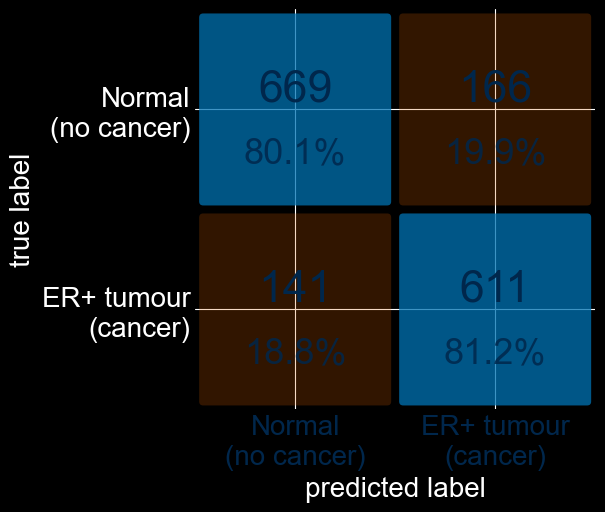

In [26]:
figure_for_poster(avg_report, "Normal", "ER+ tumour")

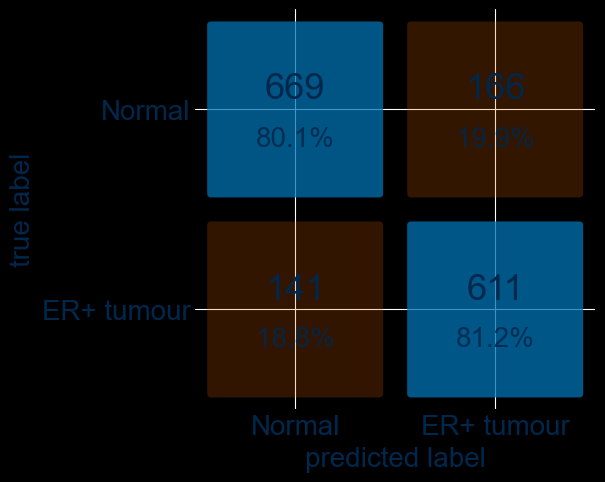

In [27]:
figure_for_poster(avg_report, "Normal", "ER+ tumour", small=True)